In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('heart.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (1025, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
print(df['target'].value_counts())

target
1    526
0    499
Name: count, dtype: int64


In [7]:
# Drop any rows with missing values
df = df.dropna()

# Check for any non-numeric values
print(df.dtypes)
print("\nShape after cleaning:", df.shape)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Shape after cleaning: (1025, 14)


In [8]:
TARGET = 'target'  

X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("Features:", X.columns.tolist())
print("Feature count:", X.shape[1])

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Feature count: 13


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 820
Testing samples: 205


In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


In [11]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\n", classification_report(y_test, y_pred,
      target_names=['No Disease', 'Heart Disease']))

Accuracy: 98.54%

                precision    recall  f1-score   support

   No Disease       0.97      1.00      0.99       102
Heart Disease       1.00      0.97      0.99       103

     accuracy                           0.99       205
    macro avg       0.99      0.99      0.99       205
 weighted avg       0.99      0.99      0.99       205



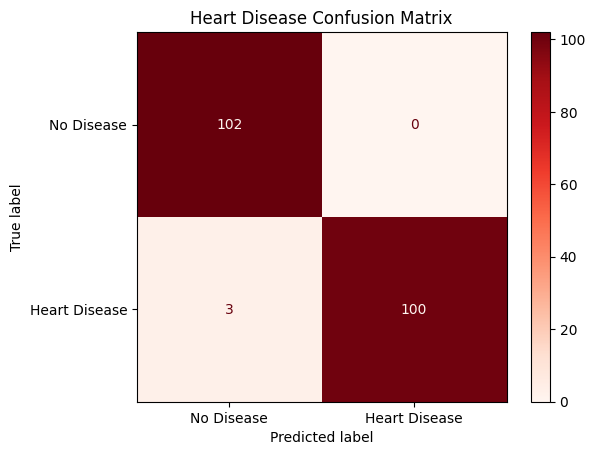

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['No Disease', 'Heart Disease'])
disp.plot(cmap='Reds')
plt.title('Heart Disease Confusion Matrix')
plt.show()

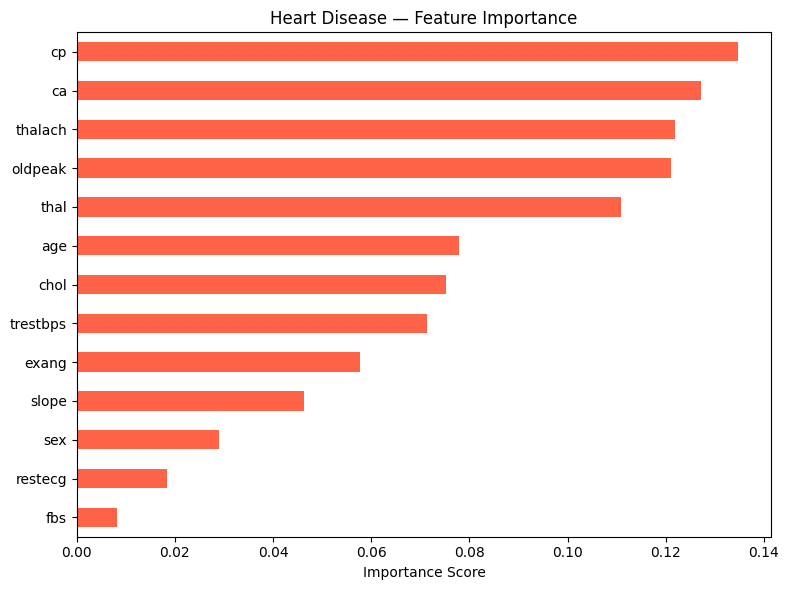

In [13]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', color='tomato', figsize=(8,6))
plt.title('Heart Disease — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [14]:
# Save model
with open('heart_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save feature names — important for correct input order
feature_names = X.columns.tolist()
with open('heart_features.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("Model saved ✅")
print("Features saved ✅")
print("Feature order:", feature_names)

Model saved ✅
Features saved ✅
Feature order: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [15]:
with open('heart_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

# Sample high risk patient
# [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
sample = [[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]]
result = loaded.predict(sample)
print("Prediction:", "Heart Disease 🔴" if result[0] == 1 else "No Heart Disease 🟢")

Prediction: Heart Disease 🔴


/Users/srushtinrao/diabetes-risk-app/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [16]:
import os
print("heart_model.pkl exists:", os.path.exists('heart_model.pkl'))
print("heart_features.pkl exists:", os.path.exists('heart_features.pkl'))

heart_model.pkl exists: True
heart_features.pkl exists: True
